# Dataset 3: EU ETS Carbon Prices Analysis

## Overview

This notebook analyzes **EU ETS Carbon Prices** - the core independent variable in our research. Carbon prices represent the market cost of emitting one tonne of CO₂ under the EU Emission Trading System.

### Research Context

Carbon prices are the **causal mechanism** we investigate:
- **Hypothesis H1 (Regulatory Drag):** High carbon prices → Increased costs → Industrial decline
- **Hypothesis H2 (Porter Hypothesis):** High carbon prices → Innovation incentives → Green growth

### Data Source

**Source:** ICE Futures Europe (via Ember Climate)  
**Unit:** EUR per tonne CO₂  
**Frequency:** Annual averages (2010-2024)  
**URL:** https://ember-climate.org/data/carbon-price-viewer/

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
DATA_PATH = '../../data/raw/'

In [2]:

df_carbon = pd.read_csv(f'{DATA_PATH}eu_ets_carbon_prices.csv')
display(df_carbon.head(10))

,year,carbon_price_eur_tonne,price_volatility_std,ets_phase,msr_active,high_price_regime,price_yoy_change_pct,price_regime
0,2010,14.32,3.2,2,0,0,NaN,Medium (€10-50)
1,2011,13.82,2.8,2,0,0,-3.49,Medium (€10-50)
2,2012,7.34,2.1,2,0,0,-46.89,Low (<€10)
3,2013,4.46,1.2,3,0,0,-39.24,Low (<€10)
4,2014,5.96,1.4,3,0,0,33.63,Low (<€10)
5,2015,7.68,1.6,3,0,0,28.86,Low (<€10)
6,2016,5.35,1.1,3,0,0,-30.34,Low (<€10)
7,2017,5.83,1.3,3,0,0,8.97,Low (<€10)
8,2018,15.83,5.2,3,0,0,171.53,Medium (€10-50)
9,2019,24.84,4.8,3,1,0,56.92,Medium (€10-50)


### ETS Phase Evolution

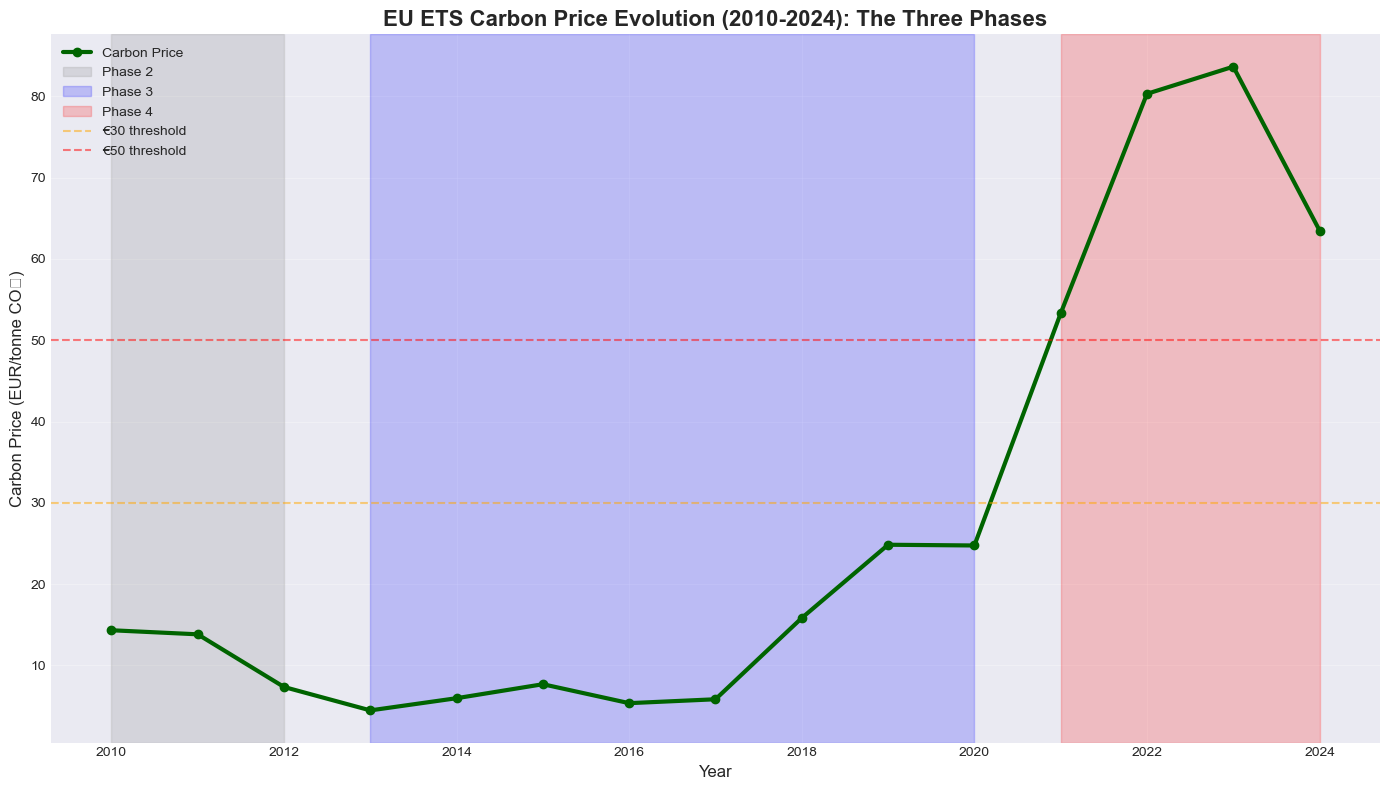

In [4]:

plt.figure(figsize=(14, 8))
plt.plot(df_carbon['year'], df_carbon['carbon_price_eur_tonne'], 
         marker='o', linewidth=3, color='darkgreen', label='Carbon Price')

plt.axvspan(2010, 2012, alpha=0.2, color='gray', label='Phase 2')
plt.axvspan(2013, 2020, alpha=0.2, color='blue', label='Phase 3')
plt.axvspan(2021, 2024, alpha=0.2, color='red', label='Phase 4')

plt.axhline(y=30, linestyle='--', color='orange', alpha=0.5, label='€30 threshold')
plt.axhline(y=50, linestyle='--', color='red', alpha=0.5, label='€50 threshold')

plt.title('EU ETS Carbon Price Evolution (2010-2024): The Three Phases', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Carbon Price (EUR/tonne CO₂)', fontsize=12)
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### KEY PERIODS:
1. 2010-2012: Phase 2 (€14, post-crisis recovery)
2. 2013-2017: Collapse (€5-8, massive oversupply)
3. 2018-2020: Recovery (€15-25, MSR announcement)
4. 2021-2023: Explosion (€53-84, Phase 4 + Green Deal)
5. 2024: Stabilization (€64, market maturity)

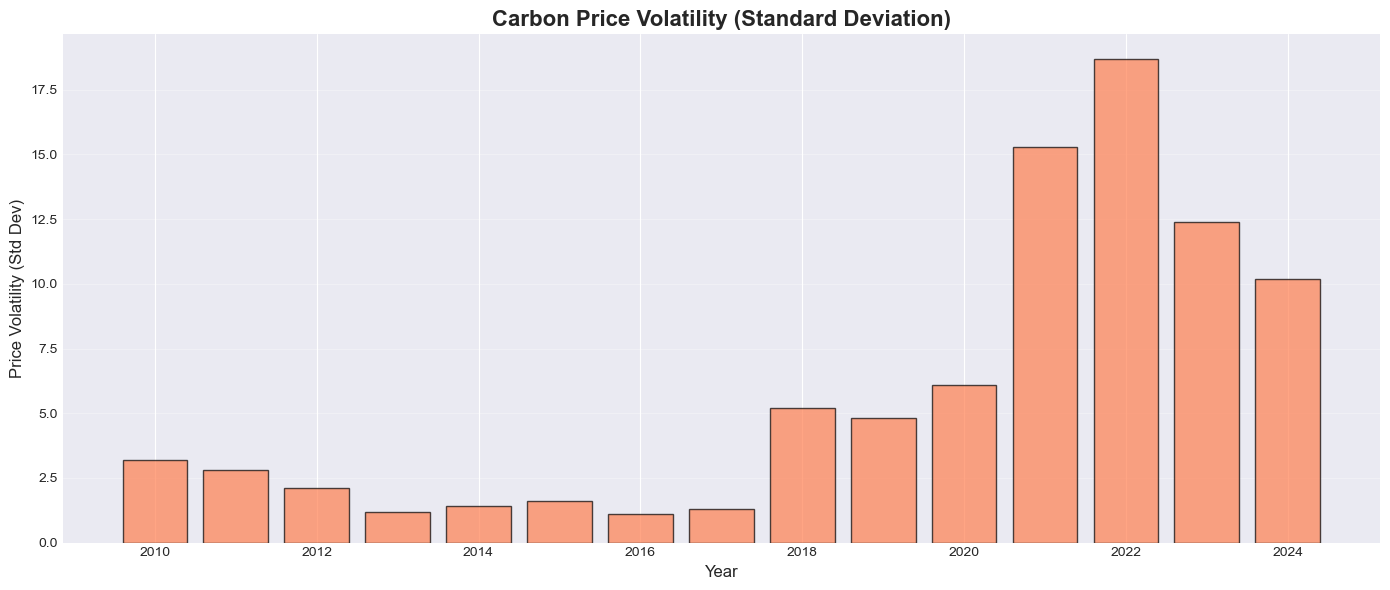

Volatility spikes in 2021-2023 indicate market uncertainty during transition


In [5]:
# Price volatility analysis
plt.figure(figsize=(14, 6))
plt.bar(df_carbon['year'], df_carbon['price_volatility_std'], 
        color='coral', alpha=0.7, edgecolor='black')
plt.title('Carbon Price Volatility (Standard Deviation)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Price Volatility (Std Dev)', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("Volatility spikes in 2021-2023 indicate market uncertainty during transition")

### Summary statistics

In [6]:
print(df_carbon[['carbon_price_eur_tonne', 'price_volatility_std']].describe())

# Phase comparison
phase_summary = df_carbon.groupby('ets_phase')['carbon_price_eur_tonne'].agg(['mean', 'min', 'max'])
print("\nPrice by ETS Phase:")
print(phase_summary)

# High price regime
high_price = df_carbon[df_carbon['high_price_regime'] == 1]
print(f"\nHigh Price Regime (>€50): {len(high_price)} years ({high_price['year'].min()}-{high_price['year'].max()})")
print(f"Average price in high regime: €{high_price['carbon_price_eur_tonne'].mean():.2f}")

       carbon_price_eur_tonne  price_volatility_std
count                15.00000             15.000000
mean                 27.39800              5.826667
std                  28.24872              5.675570
min                   4.46000              1.100000
25%                   6.65000              1.500000
50%                  14.32000              3.200000
75%                  39.07500              8.150000
max                  83.66000             18.700000

Price by ETS Phase:
                mean    min    max
ets_phase                         
2          11.826667   7.34  14.32
3          11.837500   4.46  24.84
4          70.197500  53.31  83.66

High Price Regime (>€50): 4 years (2021-2024)
Average price in high regime: €70.20


## Key Findings

1. **Structural Break in 2021:** Carbon prices quintupled from ~€15 to €80
2. **Phase 4 Impact:** The current high-price regime is unprecedented
3. **Market Volatility:** High uncertainty during 2021-2023 creates investment risk
4. **Policy Effectiveness:** Higher prices should drive emissions reductions (test in next notebooks)

### Research Implications

- **For Goal 1:** The post-2021 price shock provides natural experiment for testing Regulatory Drag
- **For Goal 3:** High prices + high volatility = "Valley of Death" hypothesis testable